<a href="https://colab.research.google.com/github/Maddox159-crypto/ESAA_assignment/blob/main/%ED%95%84%EC%82%AC24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[개념]

```

1.   토픽 모델링: 문서에 있는 토픽을 자동으로 찾아내는 기법


*   LSA
*   LDA


2.   뉴스 데이터 실습


*   피처 벡터화  :  LDA는 count 기반 벡터화만 사용
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2,
                              stop_words='english', ngram_range=(1,2))
feat_vect = count_vect.fit_transform(news_df.data)
*   LDA 모델 학습  
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)  

cf) n_components: 찾으려는 토픽 개수  
components_의 i행, j열: j번쨰 워드가 i번째 토픽에 얼마나 연관되는지를 나타내는 수치


*   display_topics(): 각 토픽마다 argsort()로 값이 큰 순서대로 워드 정렬 -> 상위 n개 인덱스 추출 -> feature_names에서 해당 인덱스의 실제 단어를 나열함.




3.   코사인 유사도: 문서 간 유사도 비교시 가장 많이 쓰임. 벡터의 크기가 아닌 방향이 얼마나 비슷한지를 기준으로 유사도를 측정함.


*   코드  
def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
    return dot_product / l2_norm
*   특징: 희소 행렬 및 밀집 행렬 모두 입력 가능함(별도의 변환이 필요 없음)  
자기 자신과의 유사도는 항상1임  
pair 형태로 한번에 여러 문서의 유사도를 --> (N. N) 형태


```

[필사]

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
        'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']
news_df = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quptes'),
                             categories=cats, random_state=0)
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english',
                           ngram_range=(1,2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [ ]:
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [ ]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[3.78057184e+00, 3.17975337e+01, 1.25038168e-01, ...,
        2.71124908e+02, 1.25078833e-01, 9.35310719e+01],
       [3.71159655e+02, 1.92194379e+02, 1.76697759e+02, ...,
        9.80144934e+00, 2.61159240e+02, 2.71639665e+01],
       [1.11423271e+02, 8.40383009e+00, 9.19047143e+00, ...,
        5.36090114e+00, 6.69702579e+00, 1.97102808e+00],
       ...,
       [1.25082611e-01, 2.13763655e-01, 6.79494190e+00, ...,
        5.87697289e+01, 3.66878463e-01, 1.43966492e+01],
       [1.25276364e-01, 4.34244341e+01, 6.73286609e-01, ...,
        1.55582529e+02, 1.04098701e+01, 7.97260104e+01],
       [5.03871007e+01, 1.25063184e-01, 8.68531213e+01, ...,
        1.25867145e+02, 1.25045966e-01, 3.97906542e+01]])

In [ ]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes = topic_word_indexes[:no_top_words]
        feature_concat = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)
feature_names = count_vect.get_feature_names_out()
display_topics(lda, feature_names, 15)

Topic # 0
just like don know writes people time article ve com think good said way going
Topic # 1
armenian armenians armenia 00 university new information russian azerbaijan 03 04 list 02 york edu
Topic # 2
image edu graphics available file software jpeg ftp dos version color images data files pub
Topic # 3
israel jews people israeli turkish jewish arab war government state said medical muslims world turkey
Topic # 4
use output file program entry line number current ground build water rules lines circuit include
Topic # 5
window use thanks does know using like server help problem application need motif display widget
Topic # 6
edu writes article com year writes article think don cs game good just team like baseball
Topic # 7
god people edu jesus believe church think does christ christian say know christians writes don


In [ ]:
import numpy as np

def cos_similarity(v1, v2):
  dot_product = np.dot(v1, v2)
  l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
  similarity = dot_product /l2_norm
  return similarity

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
doc_list = ['if you take the blue pill, the story ends',
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']
tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)


(3, 18)


In [ ]:
feature_vect_dense = feature_vect_simple.todense()
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect2 )
print('문장1, 문장2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장1, 문장2 Cosine 유사도: 0.402


In [ ]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3)
print('문장1, 문장3 Cosine 유사도: {0:.3f}'.format(similarity_simple))
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3)
print('문장2, 문장3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장1, 문장3 Cosine 유사도: 0.404
문장2, 문장3 Cosine 유사도: 0.456


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_siple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_siple_pair)

[[1.         0.40207758 0.40425045]]


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [ ]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [ ]:
import nltk

from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

from google.colab import drive

drive.mount('/content/drive')
 # 드라이브에서 불러올 경우

# 필수 NLTK 데이터 다운로드

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('wordnet')


def LemNormalize(text):

    lemmatizer = WordNetLemmatizer()

    return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]


Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
path = '/content/drive/MyDrive/ESAA/opinosis+opinion+frasl+review/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []
for file_ in all_files:
  df = pd.read_table(file_, index_col=0, header=0, encoding='latin1')
  filename_ = os.path.basename(file_)
  filename = filename_.split('.')[0]
  filename_list.append(filename)
  opinion_text.append(df.to_string())
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                              ngram_range=(1,2), min_df=0.05, max_df=0.85)
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
km_cluster = KMeans(n_clusters=3, max_iter = 10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_
document_df['cluster_label'] = cluster_label

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


In [ ]:
print(len(document_df))
print(document_df['opinion_text'].iloc[0][:300])

51
/content/drive/MyDrive/ESAA/opinosis+opinion+frasl+review/OpinosisDataset1


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
hotel_indexes = document_df[document_df['cluster_label']==2].index
print('호텔로 크러스터링 된 문서들의 DataFrame Index:', hotel_indexes)
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명', comparision_docname, '와 타 문서 유사도#####')

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)


호텔로 크러스터링 된 문서들의 DataFrame Index: Index([0, 7, 8, 12, 16, 17, 33, 34, 38, 39, 40, 43, 44, 45, 47, 49, 50], dtype='int64')
##### 비교 기준 문서명 display_garmin_nuvi_255W_gps 와 타 문서 유사도#####
[[1.         0.02309352 0.03336041 0.07346873 0.0284315  0.02288201
  0.29858128 0.11949285 0.0291962  0.06498712 0.10220501 0.05281033
  0.21899963 0.48103834 0.02617378 0.08193294 0.0191121 ]]


가장 유사도가 큰 파일명 및 유사도:
 filename      speed_garmin_nuvi_255W_gps
similarity                      0.481038
Name: 45, dtype: object


Text(0.5, 1.0, 'display_garmin_nuvi_255W_gps')

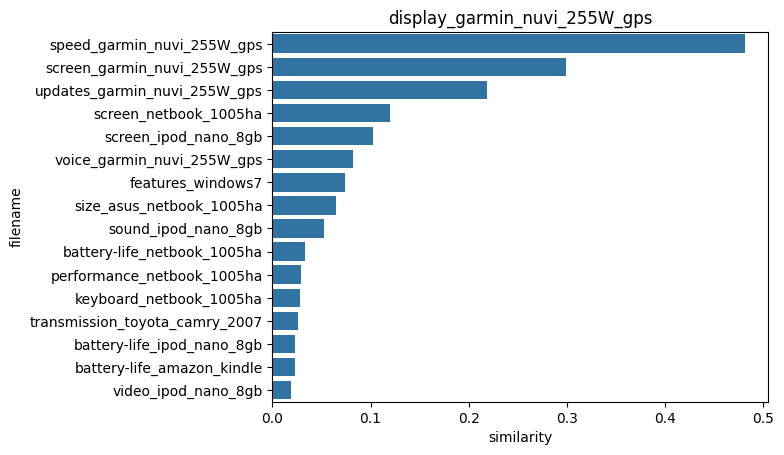

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]

# 유사도가 큰 순으로 hotel_indexes를 추출하여 재정렬.
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 유사도가 큰 순으로 정렬된 인덱스와 유사도 값을 이용해 파일명과 유사도값을 막대 그래프로 시각화
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

In [ ]:
import pandas as pd

train_df = pd.read_csv('ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [ ]:
train_df['label'].value_counts()

,count
label,
0,75173
1,74827


In [ ]:
import re

train_df = train_df.fillna(' ')
train_df['document'] = train_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )

test_df = pd.read_csv('ratings_test.txt', sep='\t', encoding='utf-8')   # 파일명 수정
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )

train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 44.9 MB/s eta 0:00:00


In [ ]:
from konlpy.tag import Okt
twitter = Okt()

def tw_tokenizer(text):
    # 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
    tokens_ko = twitter.morphs(text)
    return tokens_ko

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Twitter 객체의 morphs() 객체를 이용한 tokenizer를 사용. ngram_range는 (1, 2)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# 로지스틱 회귀를 이용해 감성 분석 분류 수행.
lg_clf = LogisticRegression(random_state=0, solver='liblinear')

# 파라미터 C 최적화를 위해 GridSearchCV를 이용.
params = { 'C': [1, 3.5, 4.5, 5.5, 10] }
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])

print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


In [ ]:
from sklearn.metrics import accuracy_score

# 학습 데이터를 적용한 TfidfVectorizer를 이용해 테스트 데이터를 TF-IDF 값으로 피처 변환함.
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

# classifier는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용
best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)

print('Logistic Regression 정확도: ', accuracy_score(test_df['label'], preds))

Logistic Regression 정확도:  0.86172
